In [7]:
import pandas as pd
import scipy.stats as stats

url = "https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/penguins_cleaned.csv"
df = pd.read_csv(url)
df.head(2)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,male
1,Adelie,Torgersen,39.5,17.4,186,3800,female


In [8]:
for col1 in df.columns:
    for col2 in df.columns:
        iscol1num = pd.api.types.is_numeric_dtype(df[col1])
        iscol2num = pd.api.types.is_numeric_dtype(df[col2])
        if col1 == col2:
            continue
        if not iscol1num or not iscol2num:
            continue
        r, p = stats.pearsonr(df[col1], df[col2])
        print(f"{col1}-{col2} : r={r:.3f}, p={p:.3f}")
            

bill_length_mm-bill_depth_mm : r=-0.229, p=0.000
bill_length_mm-flipper_length_mm : r=0.653, p=0.000
bill_length_mm-body_mass_g : r=0.589, p=0.000
bill_depth_mm-bill_length_mm : r=-0.229, p=0.000
bill_depth_mm-flipper_length_mm : r=-0.578, p=0.000
bill_depth_mm-body_mass_g : r=-0.472, p=0.000
flipper_length_mm-bill_length_mm : r=0.653, p=0.000
flipper_length_mm-bill_depth_mm : r=-0.578, p=0.000
flipper_length_mm-body_mass_g : r=0.873, p=0.000
body_mass_g-bill_length_mm : r=0.589, p=0.000
body_mass_g-bill_depth_mm : r=-0.472, p=0.000
body_mass_g-flipper_length_mm : r=0.873, p=0.000


In [9]:
r,p = stats.pearsonr(df["body_mass_g"], df["bill_length_mm"])
r2 = r**2

print(r,p,r2)

0.589451110176949 1.5386135144860187e-32 0.34745261128883764


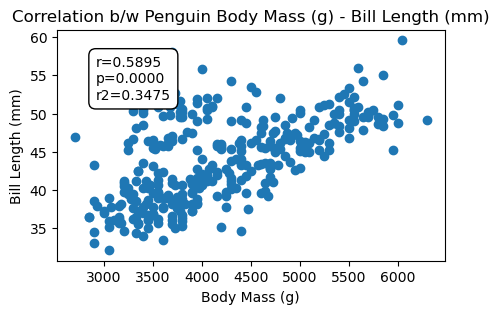

In [10]:
#create a scatter plot with matplot lib
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
text = f"""r={r:.4f}
p={p:.4f}
r2={r2:.4f}"""
plt.scatter(df["body_mass_g"], df["bill_length_mm"])
plt.xlabel("Body Mass (g)")
plt.ylabel("Bill Length (mm)")
plt.text(
    0.1,
    0.7,
    text,
    transform=plt.gca().transAxes,
    bbox={"boxstyle":"round, pad=0.5", "fc":"white"}
)
plt.title("Correlation b/w Penguin Body Mass (g) - Bill Length (mm)")
plt.show()

r value = .58 = almost moderately strong, positive correlation, as x goes up y goes up
p value = 0.0 = significant, not likely that r value is caused by chance alone
r2 = 34.75% of the movement in y is determined by the movement in x 

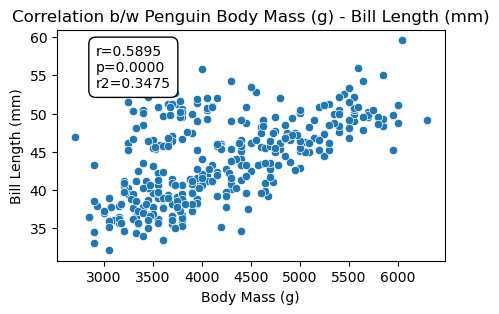

In [13]:
# do above with seaborn
import seaborn as sns

plt.figure(figsize=(5,3))
scat = sns.scatterplot(data=df, x="body_mass_g", y="bill_length_mm")
scat.text(
    0.1,
    0.75,
    text,
    transform=scat.transAxes,
    bbox={"boxstyle":"round, pad=0.5", "fc":"white"}
)
scat.set(xlabel= "Body Mass (g)", ylabel= "Bill Length (mm)", title= "Correlation b/w Penguin Body Mass (g) - Bill Length (mm)")
plt.show()

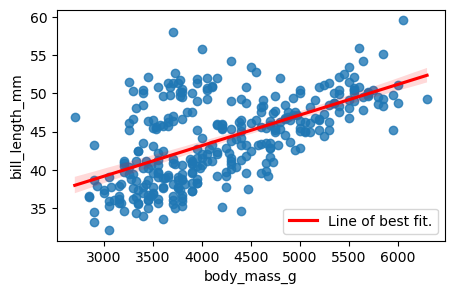

In [15]:
plt.figure(figsize=(5,3))
reg = sns.regplot(
    data=df, 
    x="body_mass_g", 
    y="bill_length_mm",
    line_kws={"color":"red", "label": "Line of best fit."})
plt.legend()

In [16]:
ret = stats.linregress(df["body_mass_g"], df["bill_length_mm"])
ret

LinregressResult(slope=np.float64(0.004003290320414926), intercept=np.float64(27.150721998842975), rvalue=np.float64(0.589451110176949), pvalue=np.float64(1.5386135144859823e-32), stderr=np.float64(0.00030155138511226586), intercept_stderr=np.float64(1.2916032123437233))

slope = m
intercept = b
r value = r
p value = p
stderr = standard error

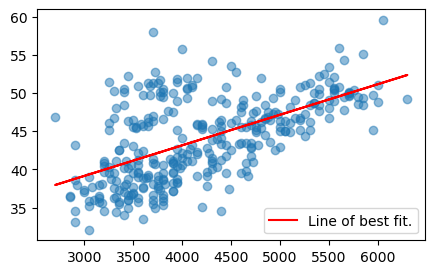

In [17]:
x = df["body_mass_g"]
y = df["bill_length_mm"]

m, b, r_val, p_val, err = stats.linregress(df["body_mass_g"], df["bill_length_mm"])
# y = m(x) + b
line = m * x + b

plt.figure(figsize=(5,3))
plt.scatter(x,y, alpha=0.5)
plt.plot(x, line, color="red", label="Line of best fit.") #add line
plt.legend()
plt.show()



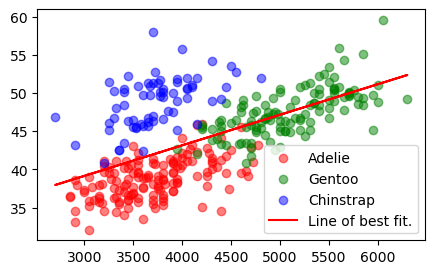

In [18]:
plt.figure(figsize=(5,3))
colors = ["red", "green", "blue"]
for species in df["species"].unique():
    subset = df.loc[df["species"] == species]
    x1 = subset["body_mass_g"]
    y1 = subset["bill_length_mm"]
    plt.scatter(x1,y1,alpha=0.5, label=species, color=colors.pop(0))
plt.plot(x,line,color="red",label="Line of best fit.")
plt.legend()
plt.show()

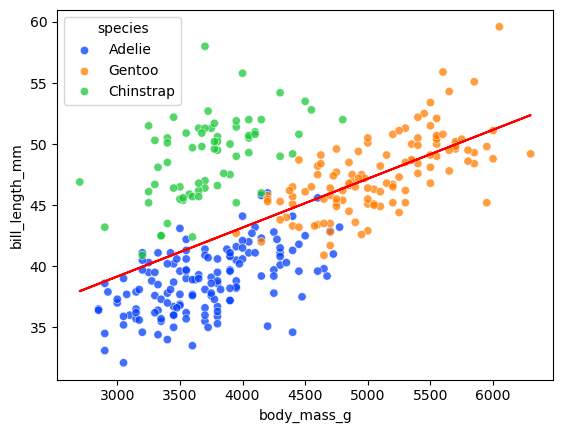

In [21]:
x_str = "body_mass_g"
y_str = "bill_length_mm"
scat = sns.scatterplot(
    data=df,
    x=x_str,
    y=y_str,
    hue="species",
    alpha=0.75,
    #palette=["orange", "blue", "green"] can create palette but you need to know how many variables you have 
    palette="bright")
plt.plot(x, line, color="red")

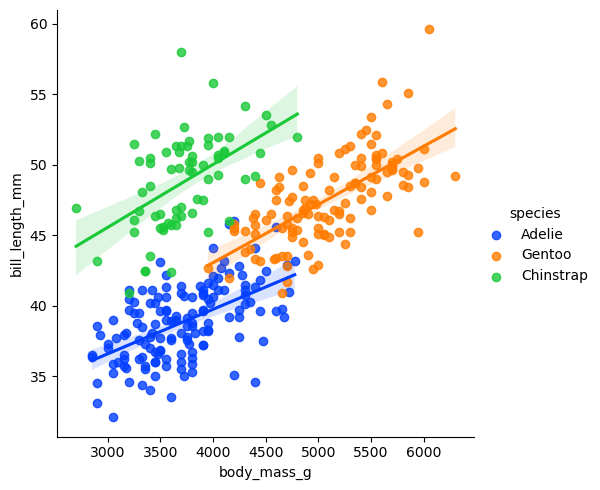

In [22]:
lm = sns.lmplot(
    data=df,
    x=x_str,
    y=y_str,
    hue="species",
    palette="bright"
)

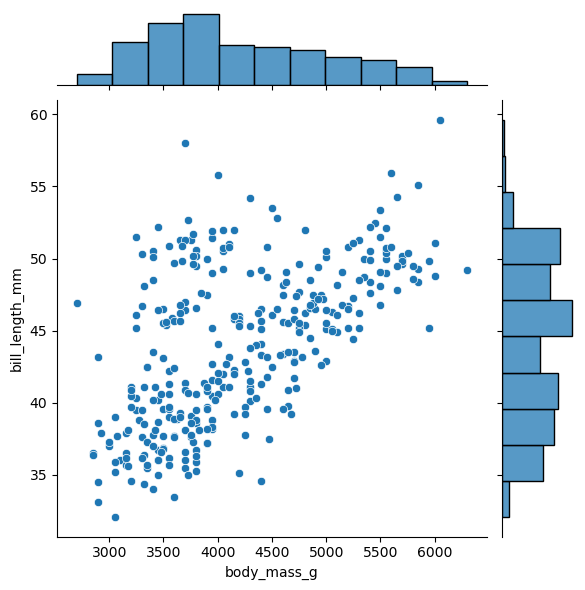

In [23]:
sns.jointplot(
    data=df,
    x=x_str,
    y=y_str,
)